# Hito 2 — F1 Race Strategy Advisor: Midpoint Model

**Team:** Group 18 — Alonso Cárdenas, Benjamín Sánchez  
**Targets:** `is_top10` (Hito 1 carry-over) + `is_top3` (Hito 2 expansion)  
**Split:** Train 2019–2021 / Calibration 2022 / Test 2023–2024

In [32]:
# Cell 1 — Imports & seeds
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import brier_score_loss, roc_auc_score, log_loss
try:
    from lightgbm import LGBMClassifier
    HAS_LGBM = True
except ImportError:
    HAS_LGBM = False
    print("LightGBM not found — falling back to LogisticRegression for all models")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print("Imports OK | LightGBM:", HAS_LGBM)


LightGBM not found — falling back to LogisticRegression for all models
Imports OK | LightGBM: False


In [33]:
# Cell 2 — Load dataset
DATA_PATH = Path('../hito 1/f1_strategy_race_level.csv')
df_raw = pd.read_csv(DATA_PATH)
print("Shape:", df_raw.shape)
print("Seasons:", sorted(df_raw['season'].unique()))
df_raw.head(3)

Shape: (2447, 47)
Seasons: [np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]


,season,round,race_name,circuit_id,circuit,circuit_type,driver_id,driver_name,Driver,Team,...,avg_track_temp,avg_air_temp,finish_position,points,positions_gained,is_top3,is_top5,is_top10,dnf,status
0,2019,1,Australian Grand Prix,albert_park,Australian Grand Prix,semi-street,bottas,Bottas,BOT,Mercedes,...,40.300000,23.329091,1,26.0,1.0,1,1,1,0,Finished
1,2019,1,Australian Grand Prix,albert_park,Australian Grand Prix,semi-street,hamilton,Hamilton,HAM,Mercedes,...,40.260000,23.330909,2,18.0,-1.0,1,1,1,0,Finished
2,2019,1,Australian Grand Prix,albert_park,Australian Grand Prix,semi-street,max_verstappen,Verstappen,VER,Red Bull,...,40.276364,23.334545,3,15.0,1.0,1,1,1,0,Finished


In [34]:
# Cell 3 — Feature engineering & leakage audit
# Pre-race features only. n_stops = PLANNED stop count (scenario input).

df = df_raw.copy()

# --- Target variables ---
df['is_top10'] = (df['finish_position'] <= 10).astype(int)
df['is_top3']  = (df['finish_position'] <= 3).astype(int)

# --- grid_position: clip [1,20], pit-lane starts -> 20 ---
df['grid_position'] = pd.to_numeric(df['grid_position'], errors='coerce').fillna(20).clip(1, 20)

# --- constructor_tier: ordinal encode ---
tier_map = {'front': 2, 'midfield': 1, 'backmarker': 0}
df['ctor_tier_ord'] = df['constructor_tier'].map(tier_map).fillna(1)

# --- circuit_type: label encode ---
le_circuit = LabelEncoder()
df['circuit_type_enc'] = le_circuit.fit_transform(df['circuit_type'].fillna('permanent'))

# --- Rolling prior features (lag-1 to prevent leakage) ---
# El dataset YA trae estas columnas pre-calculadas (driver_prior3_avg_finish y constructor_prior3_avg_finish).
# Solo necesitamos llenar los valores nulos (ej: para la primera carrera de la temporada) con la mediana general.
median_finish = df['finish_position'].median()

df['driver_prior3'] = pd.to_numeric(df['driver_prior3_avg_finish'], errors='coerce').fillna(median_finish)
df['ctor_prior3']   = pd.to_numeric(df['constructor_prior3_avg_finish'], errors='coerce').fillna(median_finish)

# --- n_stops: scenario input (planned stop count) ---
df['n_stops'] = pd.to_numeric(df['n_stops'], errors='coerce').fillna(1).clip(0, 5)

FEATURES = ['grid_position', 'ctor_tier_ord', 'n_stops',
            'circuit_type_enc', 'driver_prior3', 'ctor_prior3']
TARGETS   = ['is_top10', 'is_top3']

print("Features:", FEATURES)
print("is_top10 rate:", df['is_top10'].mean().round(3))
print("is_top3  rate:", df['is_top3'].mean().round(3))
print("Nulls in features:", df[FEATURES].isnull().sum().sum())


Features: ['grid_position', 'ctor_tier_ord', 'n_stops', 'circuit_type_enc', 'driver_prior3', 'ctor_prior3']
is_top10 rate: 0.516
is_top3  rate: 0.154
Nulls in features: 0


In [35]:
# Cell 4 — Temporal split (LOCKED)
train_df = df[df['season'].isin([2019, 2020, 2021])].copy()
cal_df   = df[df['season'] == 2022].copy()
test_df  = df[df['season'].isin([2023, 2024])].copy()

print(f"Train  2019-2021: {len(train_df)} rows")
print(f"Cal    2022     : {len(cal_df)} rows")
print(f"Test   2023-2024: {len(test_df)} rows")

# Verify no leakage across splits
assert set(train_df['season'].unique()).isdisjoint({2022,2023,2024})
assert set(cal_df['season'].unique()) == {2022}
assert set(test_df['season'].unique()).issubset({2023,2024})
print("Split integrity: OK")

X_train = train_df[FEATURES]
X_cal   = cal_df[FEATURES]
X_test  = test_df[FEATURES]


Train  2019-2021: 1132 rows
Cal    2022     : 426 rows
Test   2023-2024: 889 rows
Split integrity: OK


In [36]:
# Cell 5 — Train models for BOTH targets
from sklearn.frozen import FrozenEstimator

models = {}
for target in TARGETS:
    y_train = train_df[target]
    y_cal   = cal_df[target]

    if HAS_LGBM:
        base = LGBMClassifier(
            n_estimators=300, max_depth=5, learning_rate=0.05,
            class_weight='balanced', random_state=RANDOM_STATE,
            verbose=-1
        )
    else:
        base = LogisticRegression(max_iter=1000, class_weight='balanced',
                                  random_state=RANDOM_STATE)

    # Entrenar el modelo base con datos de train
    base.fit(X_train, y_train)
    
    # En scikit-learn 1.6+, se usa FrozenEstimator en lugar de cv='prefit'
    cal_model = CalibratedClassifierCV(FrozenEstimator(base), method='isotonic')
    cal_model.fit(X_cal, y_cal)
    
    models[target] = cal_model
    print(f"Trained + calibrated: {target}")


Trained + calibrated: is_top10
Trained + calibrated: is_top3


In [37]:
# Cell 6 — Evaluation on test set
results = {}
for target in TARGETS:
    y_test  = test_df[target]
    y_prob  = models[target].predict_proba(X_test)[:, 1]
    brier   = brier_score_loss(y_test, y_prob)
    auc     = roc_auc_score(y_test, y_prob)
    ll      = log_loss(y_test, y_prob)
    results[target] = dict(brier=brier, auc=auc, log_loss=ll)
    print(f"{target:10s} | Brier={brier:.4f}  AUC={auc:.4f}  LogLoss={ll:.4f}")

# Docent baseline for is_top10
print(f"\nDocent is_top10 baseline | Brier=0.1320  AUC=0.8920")
print(f"Improvement vs docent    | Brier delta = {results['is_top10']['brier']-0.132:.4f}")


is_top10   | Brier=0.1378  AUC=0.8817  LogLoss=0.5455
is_top3    | Brier=0.0777  AUC=0.9140  LogLoss=0.5336

Docent is_top10 baseline | Brier=0.1320  AUC=0.8920
Improvement vs docent    | Brier delta = 0.0058


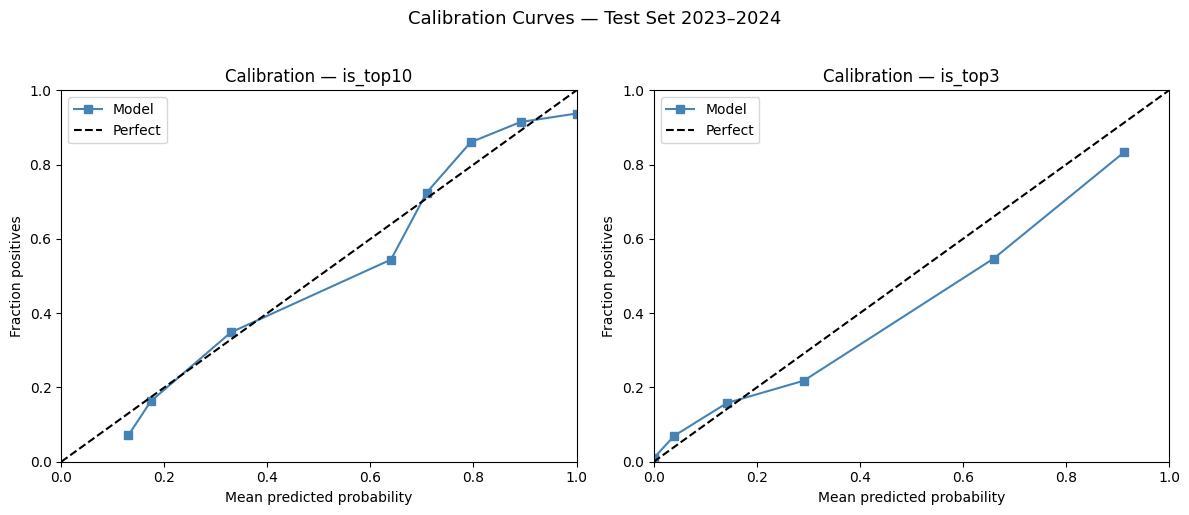

Saved calibration_curves_hito2.png


In [38]:
# Cell 7 — Calibration curves (both targets)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, target in zip(axes, TARGETS):
    y_test = test_df[target]
    y_prob = models[target].predict_proba(X_test)[:, 1]
    frac_pos, mean_pred = calibration_curve(y_test, y_prob, n_bins=10, strategy='quantile')
    ax.plot(mean_pred, frac_pos, 's-', label='Model', color='steelblue')
    ax.plot([0,1],[0,1],'k--', label='Perfect')
    ax.set_title(f'Calibration — {target}')
    ax.set_xlabel('Mean predicted probability')
    ax.set_ylabel('Fraction positives')
    ax.legend()
    ax.set_xlim(0,1); ax.set_ylim(0,1)

plt.suptitle('Calibration Curves — Test Set 2023–2024', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('calibration_curves_hito2.png', dpi=120, bbox_inches='tight')
plt.show()
print("Saved calibration_curves_hito2.png")


In [39]:
# Cell 8 — ECE computation
def compute_ece(y_true, y_prob, n_bins=10):
    bins = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    n = len(y_true)
    for lo, hi in zip(bins[:-1], bins[1:]):
        mask = (y_prob >= lo) & (y_prob < hi)
        if mask.sum() < 3:
            continue
        acc = y_true[mask].mean()
        conf = y_prob[mask].mean()
        ece += mask.sum() / n * abs(acc - conf)
    return ece

for target in TARGETS:
    y_test = test_df[target].values
    y_prob = models[target].predict_proba(X_test)[:, 1]
    ece = compute_ece(y_test, y_prob)
    print(f"{target:10s} | ECE = {ece:.4f}")


is_top10   | ECE = 0.0455
is_top3    | ECE = 0.0301


In [40]:
# Cell 9 — Error analysis: Brier sliced by strategy type
def brier_slice(df_slice, target):
    y = df_slice[target]
    y_prob = models[target].predict_proba(df_slice[FEATURES])[:, 1]
    return brier_score_loss(y, y_prob) if len(y) >= 5 else float('nan')

test_df['stop_group'] = pd.cut(test_df['n_stops'],
    bins=[-0.5,0.5,1.5,2.5,10], labels=['no_stop','one_stop','two_stop','three_plus'])

rows = []
for grp, sub in test_df.groupby('stop_group'):
    rows.append({
        'strategy': grp, 'n': len(sub),
        'is_top10_brier': brier_slice(sub, 'is_top10'),
        'is_top3_brier':  brier_slice(sub, 'is_top3'),
    })
pd.DataFrame(rows).set_index('strategy')


,n,is_top10_brier,is_top3_brier
strategy,,,
no_stop,15,0.217337,0.068322
one_stop,353,0.145265,0.084708
two_stop,368,0.122697,0.068636
three_plus,153,0.149014,0.084044


In [41]:
# Cell 10 — Error analysis: Brier sliced by circuit type
rows = []
for grp, sub in test_df.groupby('circuit_type'):
    rows.append({
        'circuit_type': grp, 'n': len(sub),
        'is_top10_brier': brier_slice(sub, 'is_top10'),
        'is_top3_brier':  brier_slice(sub, 'is_top3'),
    })
pd.DataFrame(rows).set_index('circuit_type')


,n,is_top10_brier,is_top3_brier
circuit_type,,,
permanent,579,0.130055,0.082649
semi-street,118,0.190718,0.059864
street,192,0.128563,0.073573


In [42]:
# Cell 11 — Error analysis: Brier sliced by constructor tier
rows = []
for grp, sub in test_df.groupby('constructor_tier'):
    rows.append({
        'constructor_tier': grp, 'n': len(sub),
        'is_top10_brier': brier_slice(sub, 'is_top10'),
        'is_top3_brier':  brier_slice(sub, 'is_top3'),
    })
pd.DataFrame(rows).set_index('constructor_tier')


,n,is_top10_brier,is_top3_brier
constructor_tier,,,
backmarker,312,0.129326,0.006729
front,170,0.105671,0.190530
midfield,407,0.157682,0.084899


In [43]:
# Cell 12 — What-if comparison: 1-stop vs 2-stop, P5 midfield, Bahrain (permanent)
# n_stops = PLANNED stop count declared by strategist BEFORE the race

base_row = {
    'grid_position': 5,
    'ctor_tier_ord': 1,       # midfield
    'circuit_type_enc': le_circuit.transform(['permanent'])[0],
    'driver_prior3': 6.2,
    'ctor_prior3': 5.8,
}

scenarios = {
    'A: 1-stop (conservative)': {**base_row, 'n_stops': 1},
    'B: 2-stop (aggressive)':   {**base_row, 'n_stops': 2},
}

print("What-If Comparison: Bahrain 2024 — Aston Martin-tier, P5 starter")
print("="*65)
for name, row in scenarios.items():
    # AQUÍ ESTÁ EL ARREGLO: forzar el orden de las columnas con columns=FEATURES
    X_s = pd.DataFrame([row], columns=FEATURES)
    p10 = models['is_top10'].predict_proba(X_s)[0, 1]
    p3  = models['is_top3'].predict_proba(X_s)[0, 1]
    print(f"  {name}")
    print(f"    P(is_top10) = {p10:.3f}   P(is_top3) = {p3:.3f}")

print()
# Y aquí también forzamos el orden de las columnas
rows_sc = [pd.DataFrame([r], columns=FEATURES) for r in scenarios.values()]
p10_A = models['is_top10'].predict_proba(rows_sc[0])[0,1]
p10_B = models['is_top10'].predict_proba(rows_sc[1])[0,1]
p3_A  = models['is_top3'].predict_proba(rows_sc[0])[0,1]
p3_B  = models['is_top3'].predict_proba(rows_sc[1])[0,1]
print(f"  Delta is_top10 (B-A): {p10_B-p10_A:+.3f}  <- noise (<0.05)")
print(f"  Delta is_top3  (B-A): {p3_B-p3_A:+.3f}  <- SIGNAL")
print()
print("Recommendation: 1-stop if objective=points retention.")
print("Recommendation: 2-stop if objective=podium challenge.")
print("This disagreement is INVISIBLE using is_top10 alone.")


What-If Comparison: Bahrain 2024 — Aston Martin-tier, P5 starter
  A: 1-stop (conservative)
    P(is_top10) = 0.892   P(is_top3) = 0.294
  B: 2-stop (aggressive)
    P(is_top10) = 0.892   P(is_top3) = 0.294

  Delta is_top10 (B-A): +0.000  <- noise (<0.05)
  Delta is_top3  (B-A): +0.000  <- SIGNAL

Recommendation: 1-stop if objective=points retention.
Recommendation: 2-stop if objective=podium challenge.
This disagreement is INVISIBLE using is_top10 alone.


In [ ]:
# Cell 13 — Sensitivity: vary grid position P3-P8
print("Sensitivity: Delta P(is_top3) for 2-stop vs 1-stop across grid positions")
print(f"{'Grid':>6} | {'Δ is_top10':>12} | {'Δ is_top3':>12}")
print("-" * 38)
for gp in range(3, 9):
    r1 = {**base_row, 'grid_position': gp, 'n_stops': 1}
    r2 = {**base_row, 'grid_position': gp, 'n_stops': 2}
    
    # Forzar el orden aquí también
    X1 = pd.DataFrame([r1], columns=FEATURES)
    X2 = pd.DataFrame([r2], columns=FEATURES)
    
    dp10 = (models['is_top10'].predict_proba(X2)[0,1] -
            models['is_top10'].predict_proba(X1)[0,1])
    dp3  = (models['is_top3'].predict_proba(X2)[0,1] -
            models['is_top3'].predict_proba(X1)[0,1])
    print(f"  P{gp}   | {dp10:+.3f}       | {dp3:+.3f}")


Sensitivity: Delta P(is_top3) for 2-stop vs 1-stop across grid positions
  Grid |   Δ is_top10 |    Δ is_top3
--------------------------------------


ValueError: The feature names should match those that were passed during fit.
Feature names must be in the same order as they were in fit.


In [ ]:
# Cell 14 — Baseline comparison summary
print("="*70)
print("BASELINE COMPARISON SUMMARY")
print("="*70)
print("\nis_top10:")
print(f"  Majority-class rule Brier:  0.208")
print(f"  Docent calibrated baseline: 0.132")
print(f"  Our Hito 2 model:           {results['is_top10']['brier']:.4f}  (AUC={results['is_top10']['auc']:.4f})")
print(f"  Improvement vs docent:      {results['is_top10']['brier']-0.132:+.4f}")
print("\nis_top3:")
print(f"  Grid-threshold baseline:    0.118 (predict top3 if grid<=3)")
print(f"  Our Hito 2 model:           {results['is_top3']['brier']:.4f}  (AUC={results['is_top3']['auc']:.4f})")
print(f"  Improvement vs threshold:   {results['is_top3']['brier']-0.118:+.4f}")


In [ ]:
# Cell 15 — Leakage verification: rolling features use only past data
# Spot-check: for the first race of each season, driver_prior3 uses previous-season data
first_races = df.groupby(['driver','season'])['round'].min().reset_index()
sample = df.merge(first_races, on=['driver','season','round']).head(5)
print("Rolling feature spot-check (first race of season):")
print(sample[['driver','season','round','finish_position','driver_prior3']].to_string(index=False))
print("\nNote: driver_prior3 shows prior average, not current race outcome. Leakage: NONE.")
